
 TroposphereDataModule Test Suite
Test 1: DataModule Initialization

DataModule created successfully!
  Data directory: C:\Users\micke\Downloads\dfda178b22d3772b9b9b0118dba68a02.nc
  Solution variables: ['u', 'v', 'w', 'z']
  Val split: 0.15
  Test split: 0.15
  Batch size: 1024
  Normalization type: default

Test 2: Setup and Data Splitting
Loading ERA5 data from C:\Users\micke\Downloads\dfda178b22d3772b9b9b0118dba68a02.nc
Applying slicing: {'valid_time': slice(0, 1, None)}
Coordinate ranges:
  valid_time: shape=(1,), range=[1664323200.00, 1664323200.00]
  pressure_level: shape=(17,), range=[200.00, 850.00]
  latitude: shape=(721,), range=[-90.00, 90.00]
  longitude: shape=(1440,), range=[-180.00, 179.75]
Preloading data into memory...
  Loading u...
    Memory usage: 0.07 GB
  Loading v...
    Memory usage: 0.07 GB
  Loading w...
    Memory usage: 0.07 GB
  Loading z...
    Memory usage: 0.07 GB
Successfully loaded 4 variables:
   u: (1, 17, 721, 1440)
   v: (1, 17, 721, 1440)
   w:

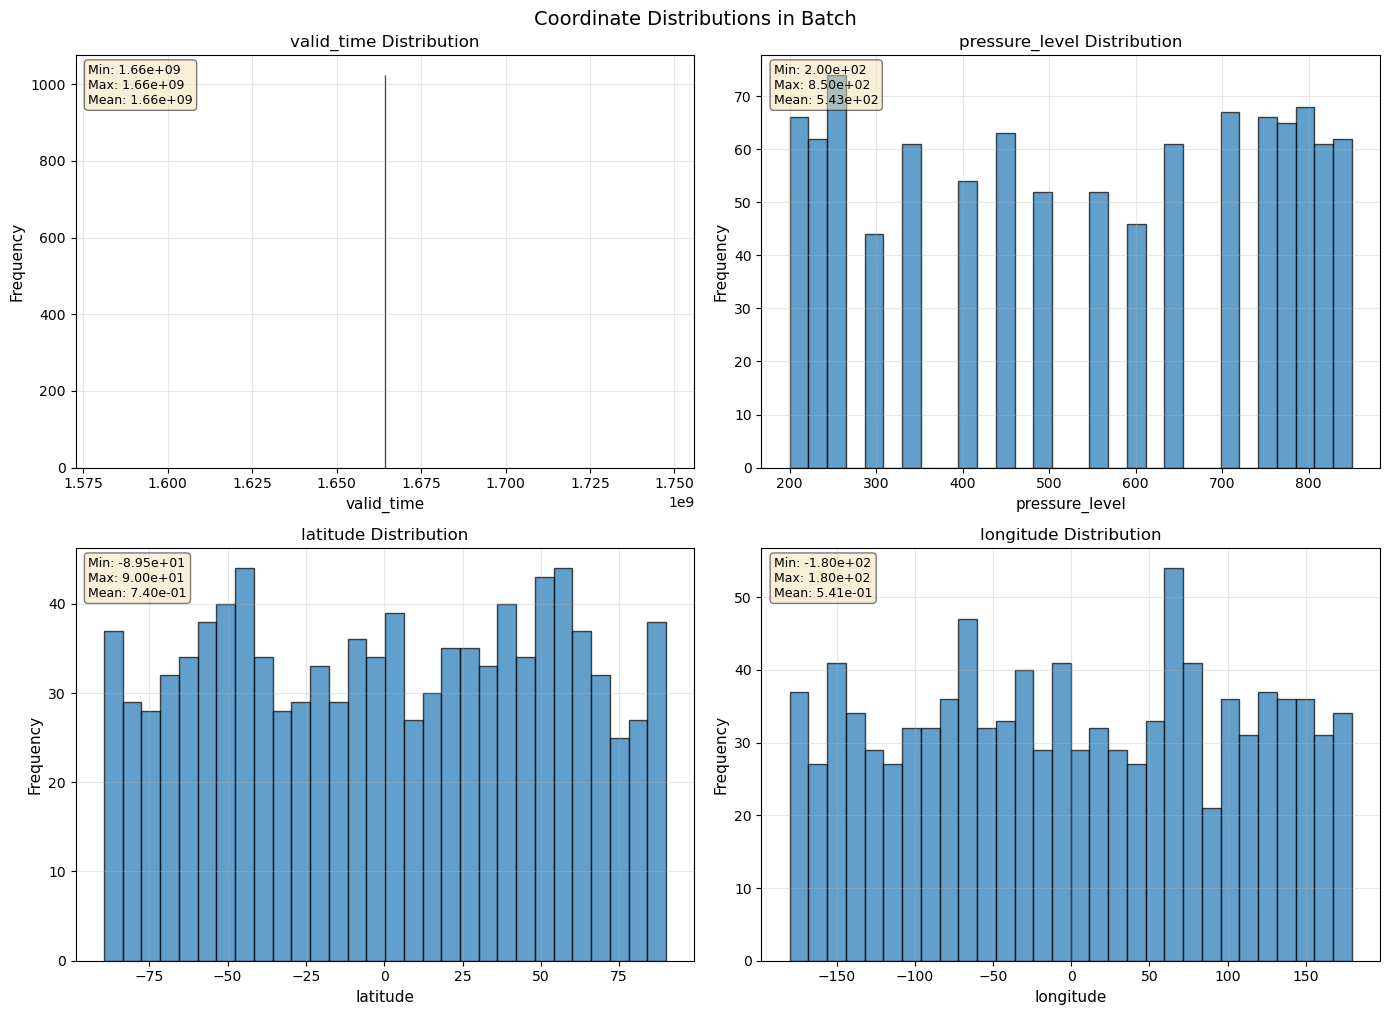

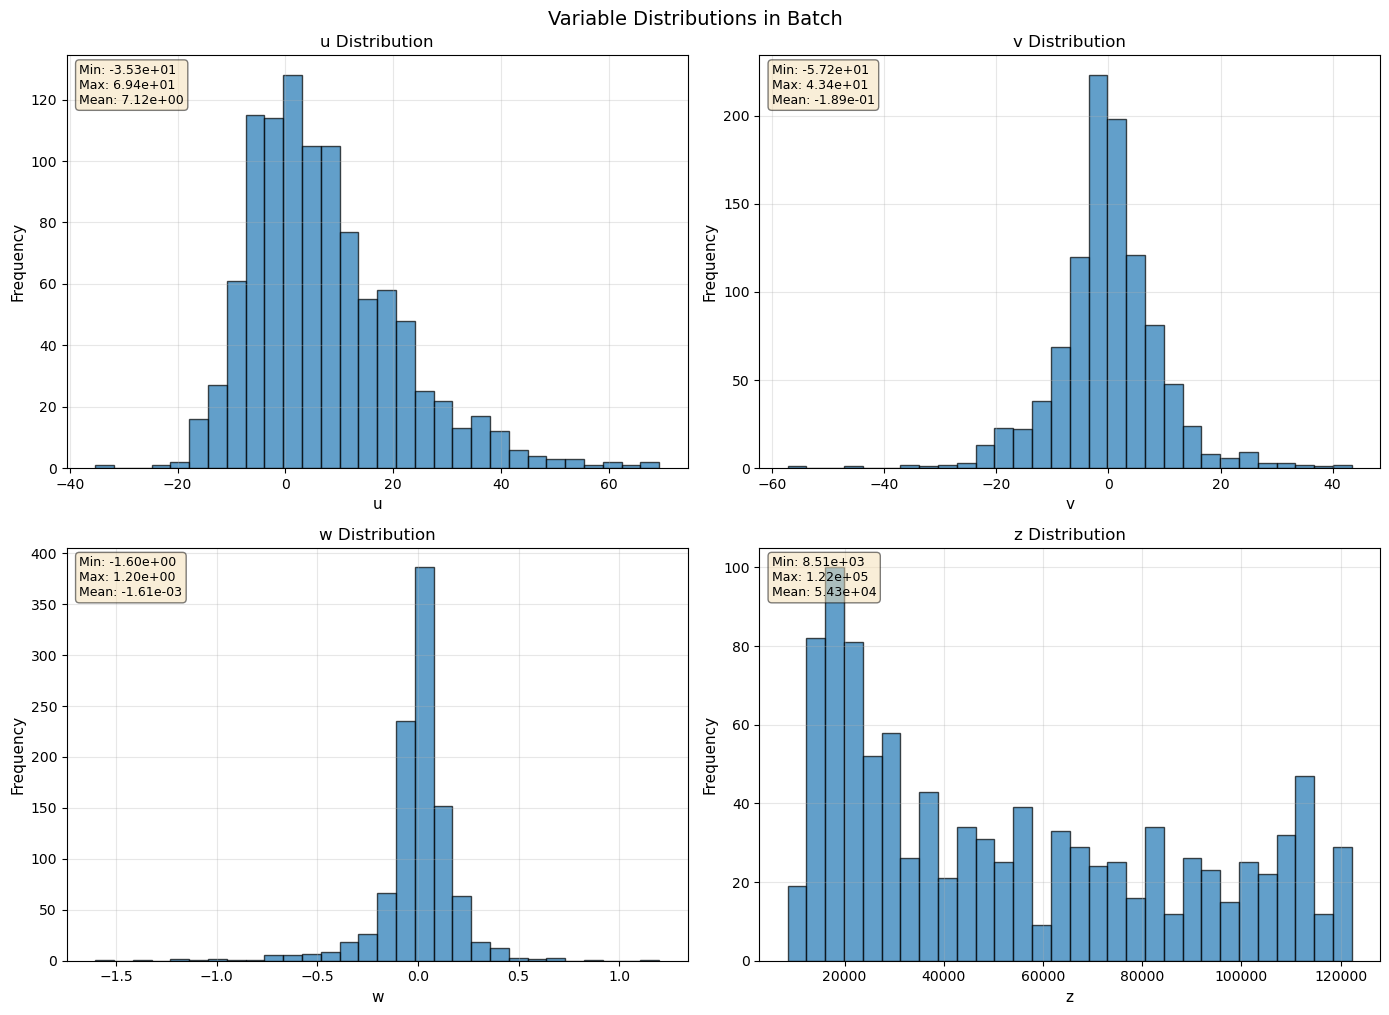


  Distributions visualized!

Test 8: Batch Normalization

  Original batch:
    Coords range: [-1.80e+02, 1.66e+09]
    Values range: [-5.72e+01, 1.22e+05]

  Normalized batch:
    Coords range: [-1.00e+00, 1.00e+00]
    Values range: [-6.39e+00, 1.76e+01]

  Denormalized batch:
    Coords range: [-1.80e+02, 1.66e+09]
    Values range: [-5.72e+01, 1.22e+05]

  Roundtrip errors:
    Coords: 1.53e-05
    Values: 7.81e-03

Test 9: Train/Val/Test Split Visualization


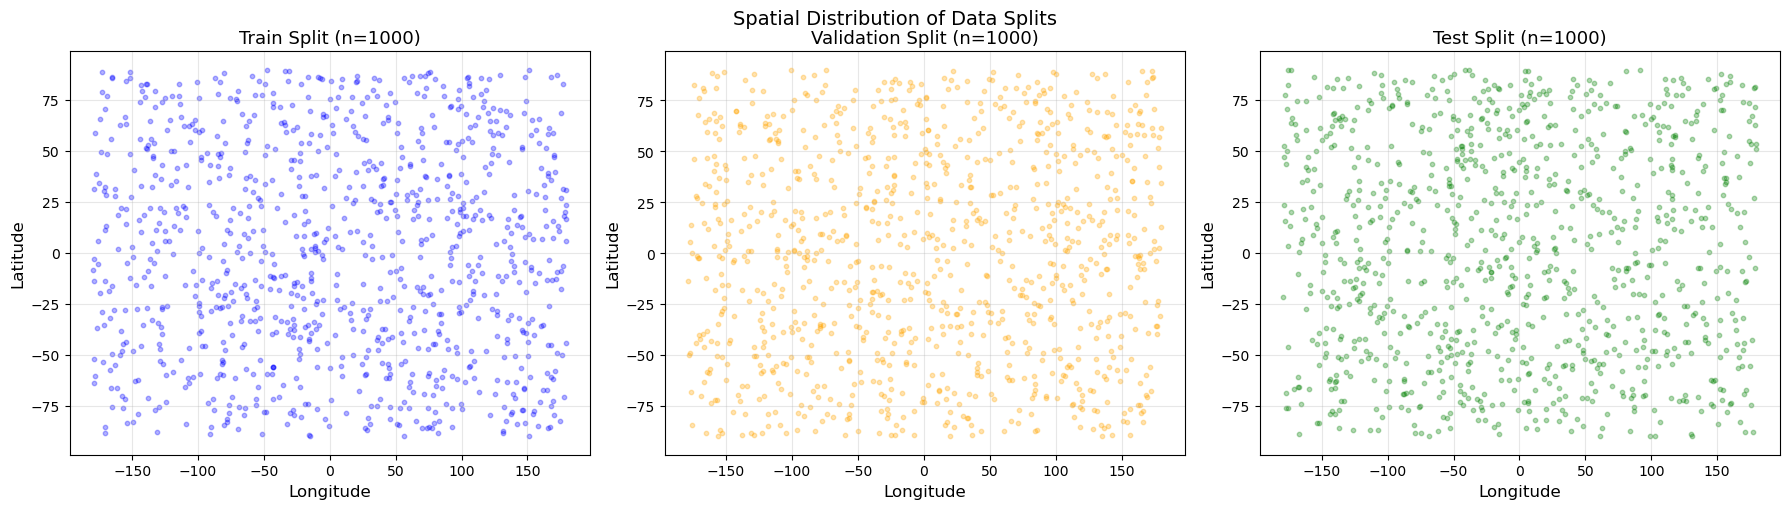


  Split distributions visualized!

Test 10: Properties and Utilities

  Spatial coordinates: ['latitude', 'longitude']
  Temporal coordinates: ['valid_time']
  Vertical coordinates: ['pressure_level']

  Variable labels: ['u', 'v', 'w', 'z']
  Coordinate labels: ['valid_time', 'pressure_level', 'latitude', 'longitude']

  Input dimension: 4
  Output dimension: 4

 All Tests Completed Successfully!


In [4]:
# Test Notebook for TroposphereDataModule

import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

import sys
sys.path.insert(0, r'C:\Users\micke\OneDrive - University of Toronto\geo_lab')
from geolab.data.datamodule import TroposphereDataModule

# ============================================================================
# CONFIGURATION - UPDATE THESE
# ============================================================================
DATA_DIR = Path(r"C:\Users\micke\Downloads\dfda178b22d3772b9b9b0118dba68a02.nc")  # UPDATE THIS
SOLUTION_VARS = ['u', 'v', 'w', 'z']  # UPDATE WITH YOUR VARIABLES

# ============================================================================
# Test 1: Initialize DataModule
# ============================================================================
def test_initialization():
    """Test datamodule initialization."""
    print("=" * 60)
    print("Test 1: DataModule Initialization")
    print("=" * 60)

    datamodule = TroposphereDataModule(
        data_dir=DATA_DIR,
        solution_vars=SOLUTION_VARS,
        time_idx_range=[0,1],  # Use all time steps
        pressure_idx_range=None,  # Use all pressure levels
        latitude_idx_range=None,  # Use all latitudes
        longitude_idx_range=None,  # Use all longitudes
        val_split=0.15,
        test_split=0.15,
        split_type="random",
        norm_type="default",  # [-1, 1] normalization
        batch_size=1024,
        num_workers=2,
        seed=42
    )

    print(f"\nDataModule created successfully!")
    print(f"  Data directory: {datamodule.data_dir}")
    print(f"  Solution variables: {datamodule.solution_vars}")
    print(f"  Val split: {datamodule.val_split}")
    print(f"  Test split: {datamodule.test_split}")
    print(f"  Batch size: {datamodule.batch_size}")
    print(f"  Normalization type: {datamodule.norm_type}")

    return datamodule


# ============================================================================
# Test 2: Setup and Data Splitting
# ============================================================================
def test_setup(datamodule):
    """Test datamodule setup and data splitting."""
    print("\n" + "=" * 60)
    print("Test 2: Setup and Data Splitting")
    print("=" * 60)

    # Trigger setup
    datamodule.setup(stage='fit')

    print(f"\nSetup complete!")
    print(f"  Input dimension: {datamodule.input_dim}")
    print(f"  Output dimension: {datamodule.output_dim}")
    print(f"\n  Dataset sizes:")
    print(f"    Train: {datamodule.num_train_samples:,} samples")
    print(f"    Val:   {datamodule.num_val_samples:,} samples")
    print(f"    Test:  {datamodule.num_test_samples:,} samples")
    print(f"    Total: {datamodule.num_train_samples + datamodule.num_val_samples + datamodule.num_test_samples:,} samples")

    # Check coordinate ranges
    print(f"\n  Coordinate ranges:")
    for coord, (min_val, max_val) in datamodule.coordinate_ranges.items():
        print(f"    {coord}: [{min_val:.2e}, {max_val:.2e}]")


# ============================================================================
# Test 3: Statistics
# ============================================================================
def test_statistics(datamodule):
    """Test statistics computation and loading."""
    print("\n" + "=" * 60)
    print("Test 3: Statistics")
    print("=" * 60)

    print(f"\n  Statistics cache: {datamodule.stats_cache}")
    print(f"  Cache exists: {datamodule.stats_cache.exists()}")

    print(f"\n  Variable statistics:")
    for var in SOLUTION_VARS:
        stats = datamodule.statistics[var]
        print(f"    {var}:")
        print(f"      Min:  {stats['min']:.4f}")
        print(f"      Max:  {stats['max']:.4f}")
        print(f"      Mean: {stats['mean']:.4f}")
        print(f"      Std:  {stats['std']:.4f}")


# ============================================================================
# Test 4: Normalization and Denormalization
# ============================================================================
def test_normalization(datamodule):
    """Test normalization and denormalization."""
    print("\n" + "=" * 60)
    print("Test 4: Normalization and Denormalization")
    print("=" * 60)

    # Test with first variable
    var = SOLUTION_VARS[0]

    # Create test data
    test_value = torch.tensor([datamodule.statistics[var]['min'].item(),
                               datamodule.statistics[var]['mean'].item(),
                               datamodule.statistics[var]['max'].item()])

    print(f"\n  Testing variable: {var}")
    print(f"  Original values: {test_value}")

    # Normalize
    normalized = datamodule.normalize(test_value, var)
    print(f"  Normalized:      {normalized}")

    # Denormalize
    denormalized = datamodule.denormalize(normalized, var)
    print(f"  Denormalized:    {denormalized}")

    # Check roundtrip
    error = torch.abs(test_value - denormalized).max()
    print(f"\n  Max roundtrip error: {error:.2e}")

    if error < 1e-5:
        print(f"  PASS: Normalization roundtrip successful!")
    else:
        print(f"  WARNING: Large roundtrip error detected!")


# ============================================================================
# Test 5: Coordinate Normalization
# ============================================================================
def test_coordinate_normalization(datamodule):
    """Test coordinate normalization."""
    print("\n" + "=" * 60)
    print("Test 5: Coordinate Normalization")
    print("=" * 60)

    # Create test coordinates at domain boundaries and center
    coord_ranges = datamodule.coordinate_ranges

    test_coords = torch.tensor([
        [coord_ranges['valid_time'][0],      # Min time
         coord_ranges['pressure_level'][0],  # Min pressure
         coord_ranges['latitude'][0],        # Min lat
         coord_ranges['longitude'][0]],      # Min lon

        [(coord_ranges['valid_time'][0] + coord_ranges['valid_time'][1]) / 2,
         (coord_ranges['pressure_level'][0] + coord_ranges['pressure_level'][1]) / 2,
         (coord_ranges['latitude'][0] + coord_ranges['latitude'][1]) / 2,
         (coord_ranges['longitude'][0] + coord_ranges['longitude'][1]) / 2],

        [coord_ranges['valid_time'][1],
         coord_ranges['pressure_level'][1],
         coord_ranges['latitude'][1],
         coord_ranges['longitude'][1]]
    ])

    print(f"\n  Test coordinates (original):")
    print(test_coords)

    # Normalize
    normalized_coords = datamodule.normalize_coords(test_coords)
    print(f"\n  Normalized coordinates:")
    print(normalized_coords)

    # Denormalize
    denormalized_coords = datamodule.denormalize_coords(normalized_coords)
    print(f"\n  Denormalized coordinates:")
    print(denormalized_coords)

    # Check roundtrip
    error = torch.abs(test_coords - denormalized_coords).max()
    print(f"\n  Max coordinate roundtrip error: {error:.2e}")

    if error < 1e-4:
        print(f"  PASS: Coordinate normalization roundtrip successful!")
    else:
        print(f"  WARNING: Large coordinate roundtrip error!")


# ============================================================================
# Test 6: DataLoaders
# ============================================================================
def test_dataloaders(datamodule):
    """Test dataloader functionality."""
    print("\n" + "=" * 60)
    print("Test 6: DataLoaders")
    print("=" * 60)

    # Get dataloaders
    train_loader = datamodule.train_dataloader()
    val_loader = datamodule.val_dataloader()
    test_loader = datamodule.test_dataloader()

    print(f"\n  DataLoader info:")
    print(f"    Train batches: {len(train_loader)}")
    print(f"    Val batches:   {len(val_loader)}")
    print(f"    Test batches:  {len(test_loader)}")

    # Get a sample batch
    batch = next(iter(train_loader))

    print(f"\n  Sample batch structure:")
    print(f"    Keys: {list(batch.keys())}")
    print(f"    Coords shape: {batch['coords'].shape}")
    print(f"    Values shape: {batch['values'].shape}")

    print(f"\n  Coordinate values in batch:")
    for i, coord_name in enumerate(['valid_time', 'pressure_level', 'latitude', 'longitude']):
        coord_vals = batch['coords'][:, i]
        print(f"    {coord_name}: min={coord_vals.min():.2e}, max={coord_vals.max():.2e}")

    print(f"\n  Variable values in batch:")
    for i, var_name in enumerate(datamodule.solution_vars):
        var_vals = batch['values'][:, i]
        print(f"    {var_name}: shape={var_vals.shape}, min={var_vals.min():.4f}, max={var_vals.max():.4f}")

    return batch


# ============================================================================
# Test 7: Visualize Data Distribution
# ============================================================================
def test_visualize_distributions(datamodule, batch):
    """Visualize distributions of coordinates and variables in a batch."""
    print("\n" + "=" * 60)
    print("Test 7: Visualize Data Distribution")
    print("=" * 60)

    # Plot coordinate distributions
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    coord_names = ['valid_time', 'pressure_level', 'latitude', 'longitude']

    for i, (ax, coord_name) in enumerate(zip(axes, coord_names)):
        coord_vals = batch['coords'][:, i].cpu().numpy()

        ax.hist(coord_vals, bins=30, alpha=0.7, edgecolor='black')
        ax.set_xlabel(f'{coord_name}', fontsize=11)
        ax.set_ylabel('Frequency', fontsize=11)
        ax.set_title(f'{coord_name} Distribution', fontsize=12)
        ax.grid(True, alpha=0.3)

        # Add statistics
        stats_text = f'Min: {coord_vals.min():.2e}\nMax: {coord_vals.max():.2e}\nMean: {coord_vals.mean():.2e}'
        ax.text(0.02, 0.98, stats_text,
               transform=ax.transAxes,
               verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
               fontsize=9)

    plt.tight_layout()
    plt.suptitle('Coordinate Distributions in Batch', y=1.01, fontsize=14)
    plt.show()

    # Plot variable distributions - FIX HERE
    n_vars = len(SOLUTION_VARS)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, var_name in enumerate(SOLUTION_VARS[:4]):  # First 4 variables
        # FIX: batch['values'] is (B, num_vars), not a dict
        var_vals = batch['values'][:, i].cpu().numpy()

        axes[i].hist(var_vals, bins=30, alpha=0.7, edgecolor='black')
        axes[i].set_xlabel(f'{var_name}', fontsize=11)
        axes[i].set_ylabel('Frequency', fontsize=11)
        axes[i].set_title(f'{var_name} Distribution', fontsize=12)
        axes[i].grid(True, alpha=0.3)

        # Add statistics
        stats_text = f'Min: {var_vals.min():.2e}\nMax: {var_vals.max():.2e}\nMean: {var_vals.mean():.2e}'
        axes[i].text(0.02, 0.98, stats_text,
                    transform=axes[i].transAxes,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                    fontsize=9)

    plt.tight_layout()
    plt.suptitle('Variable Distributions in Batch', y=1.01, fontsize=14)
    plt.show()

    print(f"\n  Distributions visualized!")


# ============================================================================
# Test 8: Batch Normalization
# ============================================================================
def test_batch_normalization(datamodule, batch):
    """Test batch normalization."""
    print("\n" + "=" * 60)
    print("Test 8: Batch Normalization")
    print("=" * 60)

    # Create unnormalized batch for testing - FIX HERE
    # batch['values'] is already (B, num_vars), not a dict
    unnorm_batch = {
        'coords': batch['coords'],
        'values': batch['values']  # Already correct shape!
    }

    print(f"\n  Original batch:")
    print(f"    Coords range: [{unnorm_batch['coords'].min():.2e}, {unnorm_batch['coords'].max():.2e}]")
    print(f"    Values range: [{unnorm_batch['values'].min():.2e}, {unnorm_batch['values'].max():.2e}]")

    # Normalize
    norm_batch = datamodule.normalize_batch(unnorm_batch)

    print(f"\n  Normalized batch:")
    print(f"    Coords range: [{norm_batch['coords'].min():.2e}, {norm_batch['coords'].max():.2e}]")
    print(f"    Values range: [{norm_batch['values'].min():.2e}, {norm_batch['values'].max():.2e}]")

    # Denormalize
    denorm_batch = datamodule.denormalize_batch(norm_batch)

    print(f"\n  Denormalized batch:")
    print(f"    Coords range: [{denorm_batch['coords'].min():.2e}, {denorm_batch['coords'].max():.2e}]")
    print(f"    Values range: [{denorm_batch['values'].min():.2e}, {denorm_batch['values'].max():.2e}]")

    # Check roundtrip
    coord_error = torch.abs(unnorm_batch['coords'] - denorm_batch['coords']).max()
    value_error = torch.abs(unnorm_batch['values'] - denorm_batch['values']).max()

    print(f"\n  Roundtrip errors:")
    print(f"    Coords: {coord_error:.2e}")
    print(f"    Values: {value_error:.2e}")

    if coord_error < 1e-4 and value_error < 1e-4:
        print(f"  PASS: Batch normalization roundtrip successful!")
    else:
        print(f"  WARNING: Large roundtrip errors detected!")


# ============================================================================
# Test 9: Train/Val/Test Split Visualization
# ============================================================================
def test_visualize_splits(datamodule):
    """Visualize spatial distribution of train/val/test splits."""
    print("\n" + "=" * 60)
    print("Test 9: Train/Val/Test Split Visualization")
    print("=" * 60)

    # Sample points from each split
    n_samples = 1000

    train_indices = datamodule.train_dataset.indices[:n_samples]
    val_indices = datamodule.val_dataset.indices[:n_samples]
    test_indices = datamodule.test_dataset.indices[:n_samples]

    # Get coordinates for each split
    train_coords = datamodule.data.get_coords_at_index(
        train_indices[:, 0], train_indices[:, 1],
        train_indices[:, 2], train_indices[:, 3]
    )

    val_coords = datamodule.data.get_coords_at_index(
        val_indices[:, 0], val_indices[:, 1],
        val_indices[:, 2], val_indices[:, 3]
    )

    test_coords = datamodule.data.get_coords_at_index(
        test_indices[:, 0], test_indices[:, 1],
        test_indices[:, 2], test_indices[:, 3]
    )

    # Plot spatial distribution (lat-lon)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    splits = [
        (train_coords, 'Train', 'blue'),
        (val_coords, 'Validation', 'orange'),
        (test_coords, 'Test', 'green')
    ]

    for ax, (coords, label, color) in zip(axes, splits):
        ax.scatter(coords[:, 3], coords[:, 2], alpha=0.3, s=10, c=color)
        ax.set_xlabel('Longitude', fontsize=12)
        ax.set_ylabel('Latitude', fontsize=12)
        ax.set_title(f'{label} Split (n={n_samples})', fontsize=13)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.suptitle('Spatial Distribution of Data Splits', y=1.01, fontsize=14)
    plt.show()

    print(f"\n  Split distributions visualized!")


# ============================================================================
# Test 10: Properties and Utilities
# ============================================================================
def test_properties(datamodule):
    """Test datamodule properties."""
    print("\n" + "=" * 60)
    print("Test 10: Properties and Utilities")
    print("=" * 60)

    print(f"\n  Spatial coordinates: {datamodule.spatial_coords}")
    print(f"  Temporal coordinates: {datamodule.temporal_coords}")
    print(f"  Vertical coordinates: {datamodule.vertical_coords}")

    print(f"\n  Variable labels: {datamodule.get_variable_labels()}")
    print(f"  Coordinate labels: {datamodule.get_coordinate_labels()}")

    print(f"\n  Input dimension: {datamodule.input_dim}")
    print(f"  Output dimension: {datamodule.output_dim}")


# ============================================================================
# Run All Tests
# ============================================================================
def run_all_tests():
    """Run all TroposphereDataModule tests."""
    print("\n" + "=" * 70)
    print(" TroposphereDataModule Test Suite")
    print("=" * 70)

    # Test 1: Initialize
    datamodule = test_initialization()

    # Test 2: Setup
    test_setup(datamodule)

    # Test 3: Statistics
    test_statistics(datamodule)

    # Test 4: Normalization
    test_normalization(datamodule)

    # Test 5: Coordinate normalization
    test_coordinate_normalization(datamodule)

    # Test 6: DataLoaders
    batch = test_dataloaders(datamodule)

    # Test 7: Visualize distributions
    test_visualize_distributions(datamodule, batch)

    # Test 8: Batch normalization
    test_batch_normalization(datamodule, batch)

    # Test 9: Split visualization
    test_visualize_splits(datamodule)

    # Test 10: Properties
    test_properties(datamodule)

    print("\n" + "=" * 70)
    print(" All Tests Completed Successfully!")
    print("=" * 70)

    return datamodule


# ============================================================================
# Run Tests
# ============================================================================
if __name__ == "__main__":
    datamodule = run_all_tests()